In [1]:
import pandas as pd
import numpy as np
from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Section 01 - Effect of a third variable

In [2]:
coffee_dt = pd.read_csv('../Datasets/Exercise2_datasets/exdata 6/coffee_sim.csv')
coffee_dt.head()

,cigarette_packs_per_day,datavizitis_deaths_per_thousand,coffee_cups_per_day
0,0,5.559936,1-5
1,2,16.117006,5+
2,1,10.183569,5+
3,1,8.134044,5+
4,0,5.711944,1-5


1. Suggest an appropriate visualization and implement it with plotnine to display a possible association
between coffee consumption and “datavizitis” disease risk, measured in deaths per 1000 individuals. Does
this plot by itself seem consistent with a causal effect of coffee on datavizitis?

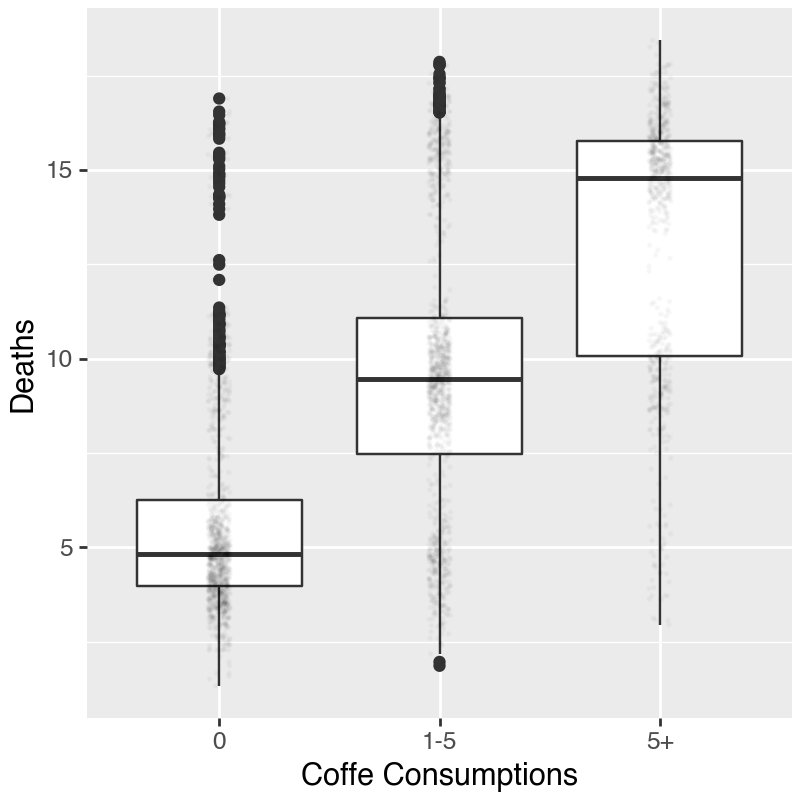

In [20]:
coffee_dt['coffee_cups_per_day'] = coffee_dt['coffee_cups_per_day'].astype('category')

(
    ggplot(coffee_dt, aes(x = 'coffee_cups_per_day', y = 'datavizitis_deaths_per_thousand')) +
    geom_boxplot() + 
    labs(x = 'Coffe Consumptions', y = 'Deaths') +
    geom_jitter(width = 0.05, alpha = 0.02, size = 0.2) +
    theme(figure_size=(4,4))
)

2. Investigate the full dataset. Do you see evidence for a third variable influencing association? Support
your statement with an appropriate plot.

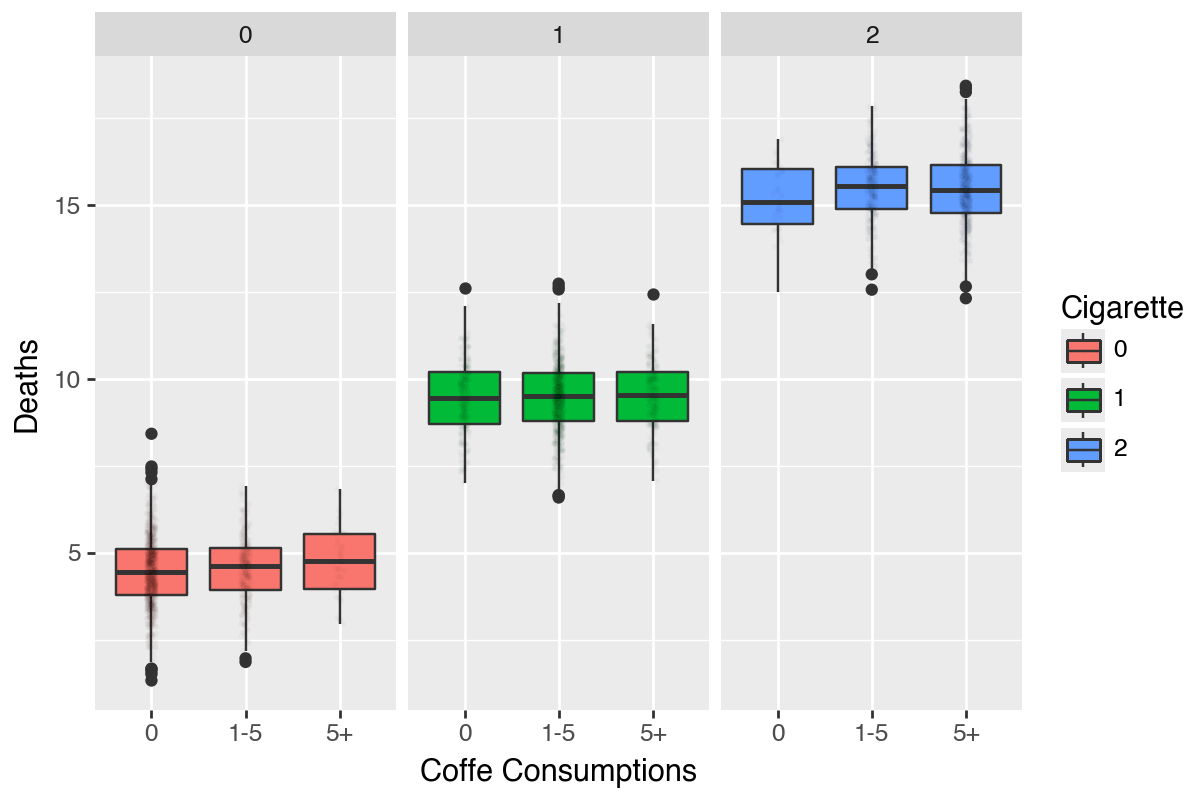

In [31]:
coffee_dt['cigarette_packs_per_day'] = coffee_dt['cigarette_packs_per_day'].astype('category')

(
    ggplot(coffee_dt, aes(x = 'coffee_cups_per_day', y = 'datavizitis_deaths_per_thousand', fill = 'cigarette_packs_per_day')) +
    geom_boxplot() + 
    labs(x = 'Coffe Consumptions', y = 'Deaths', fill = 'Cigarette') +
    geom_jitter(width = 0.05, alpha = 0.02, size = 0.2) +
    facet_wrap('~cigarette_packs_per_day') +
    theme(figure_size=(6,4))
)

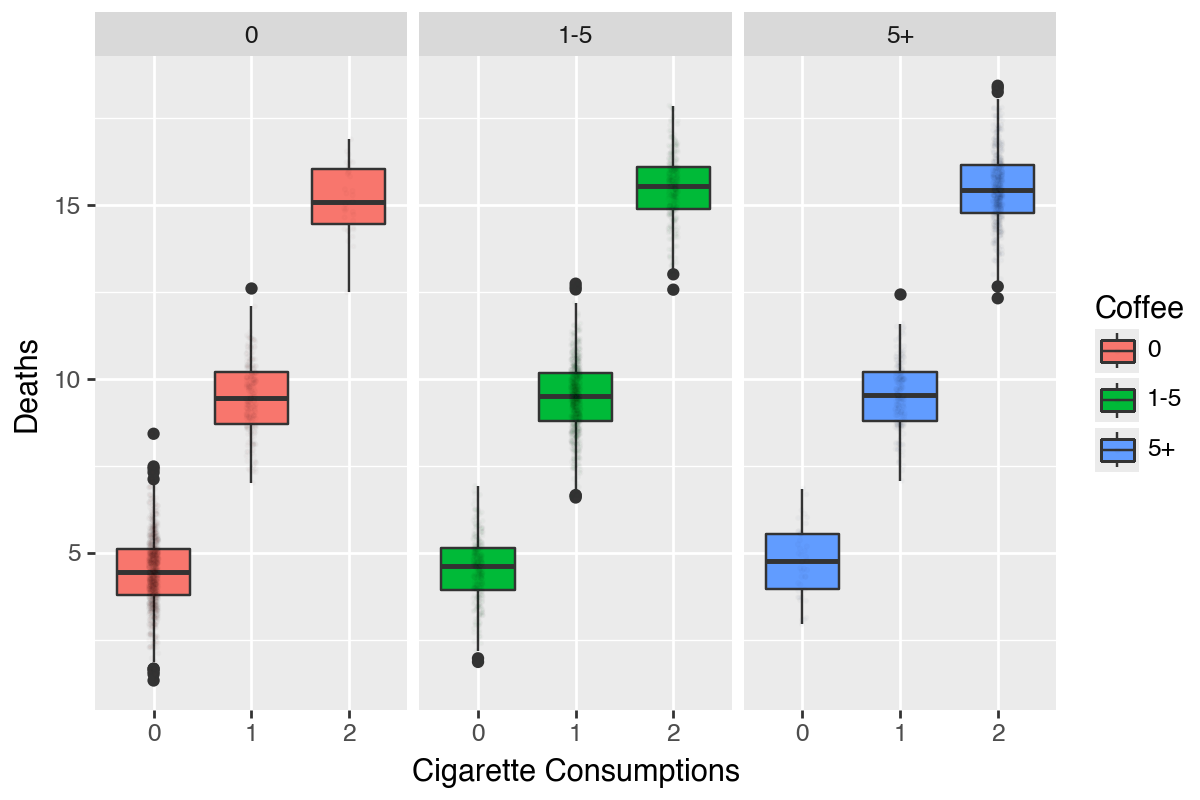

In [32]:
(
    ggplot(coffee_dt, aes(x = 'cigarette_packs_per_day', y = 'datavizitis_deaths_per_thousand', fill = 'coffee_cups_per_day')) +
    geom_boxplot() + 
    labs(x = 'Cigarette Consumptions', y = 'Deaths', fill = 'Coffee') +
    geom_jitter(width = 0.05, alpha = 0.02, size = 0.2) +
    facet_wrap('~coffee_cups_per_day') +
    theme(figure_size=(6,4))
)

3. Draw a graph with the potential causal relationships you find consistent with the data. Relate it to
one of the situations from the lecture script’s figure 6.3 or Simpson’s paradox.

Different causal relationships are valid. For example, under the assumption that people who smoke a
cigarette like to follow up with a coffee and that smoking directly influences datavizitis then this scenario
would be consistent with common cause.

<img src = '../images/Ekran Resmi 2026-02-09 12.30.42.png' width = 500>

4. Suggest another possible mechanism involving yet another variable. Draw the causal diagram

Another causal relationship would imply the effect of a 3rd variable. People who are more likely to
take drugs will also more likely take both caffeine and nicotine, while only the latter directly causes
datavizitis.

<img src = '../images/Ekran Resmi 2026-02-09 12.31.32.png' width = 500>

-----

# Section 02 - General guidelines in data visualization

Below is a graph taken from one published paper. Read the figure legend.

<img src = '../images/Ekran Resmi 2026-02-09 12.33.18.png' width = 800>

In biology, a wild type strain (WT) is a strain whose genome has not been artificially modified. In
contrast, a mutant is a strain whose genome has been artificially modified.

1. Discuss in groups what could be better representations. Use pen and paper. There can be many
options.

<u>GOOD</u>
* simple design

* not too many colors

* clear labels
    
* no chart junk

<u>BAD</u>

* no highlight, e.g. by color

* x-axis not sorted

* summary by mean+sd hides the data, which is at most four points per bar

<u>Suggestion</u>

* plot single points instead of bars, with small median line (too few points for boxplot)

* sort Mutants by median

* give color for above and below WT

2. Implement the solution proposed by the tutor using the following simulated data that approximately
mimick the original data.

In [34]:
SIMULATION_GROUPS = [
(10100, 3, "WT"), (12100, 4, "T49A"), (9850, 3, "K227N"), (11100, 4, "A400V"),
(8300, 4, "L421P"), (10050, 3, "I500T"), (12000, 3, "N591D"),
(10020, 3, "A601T"), (10080, 3, "E684D"), (10070, 3, "G710R")
]
SCALE = 300

In [38]:
pro_uptake = np.concatenate([
np.random.normal(loc=loc, scale=SCALE, size=size) for loc, size, _ in SIMULATION_GROUPS
])

mutants = np.concatenate([
np.repeat(mutant, size) for _, size, mutant in SIMULATION_GROUPS
])

dt = pd.DataFrame({'pro_uptake': pro_uptake, 'mutants': mutants})
print(dt.head())

     pro_uptake mutants
0   9851.570688      WT
1  10096.828889      WT
2  10140.796546      WT
3  11884.851952    T49A
4  11723.517455    T49A


In [46]:
summary_dt = dt.groupby('mutants')['pro_uptake'].agg(['mean','std']).reset_index()
summary_dt.head()


,mutants,mean,std
0,A400V,11089.487361,136.598354
1,A601T,9873.072658,42.641381
2,E684D,9930.432746,325.476084
3,G710R,9884.424208,56.085998
4,I500T,9908.814588,259.976818


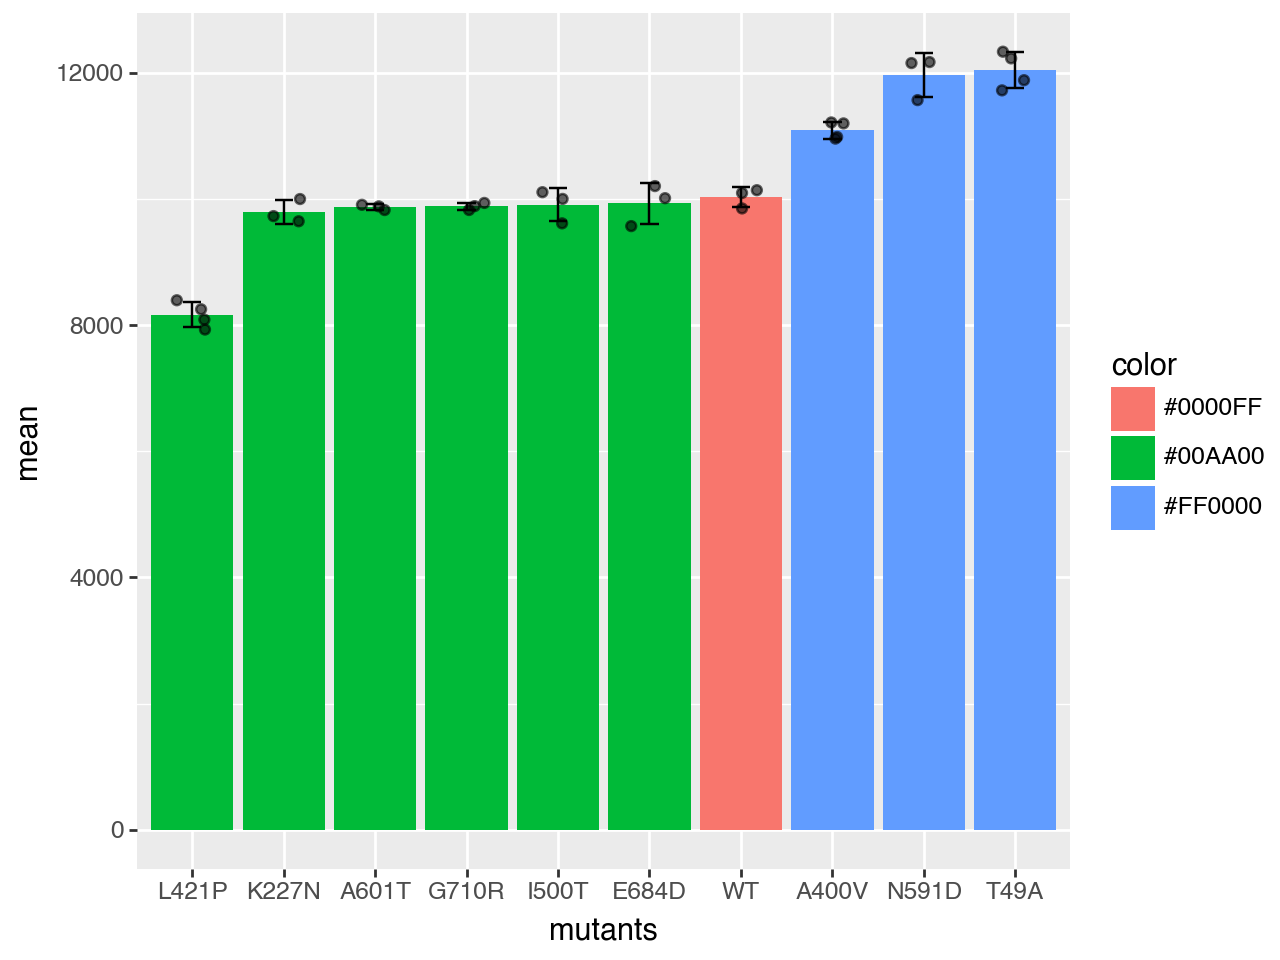

In [85]:
wt_mean = summary_dt[summary_dt['mutants'] == 'WT']['mean'].iloc[0]

x_order = summary_dt.sort_values(by = 'mean')['mutants'].tolist()

mutant_category =  pd.CategoricalDtype(categories=x_order, ordered= True)
summary_dt['mutants'] = summary_dt['mutants'].astype(mutant_category)
dt['mutants'] = dt['mutants'].astype(mutant_category)

summary_dt['color'] = np.select([summary_dt['mean'] > wt_mean, summary_dt['mutants'] == 'WT'], ['#FF0000', '#0000FF'],   # red, blue
    default='#00AA00' )

(
    ggplot(summary_dt, aes(x = 'mutants', y = 'mean', fill = 'color')) +
    geom_bar(stat = 'identity') +
    geom_errorbar(aes(ymax='mean+std', ymin='mean-std'), width=0.2, color='black') +
    geom_jitter(data=dt, mapping=aes(x = 'mutants',y='pro_uptake'), height=0, width=0.2, alpha=0.6, inherit_aes=False)
)


--------

# Section 03 - Covid19 fatality rate in Belgium

Consider the following dataset which contains the fatality rate (percentage of deaths among infected) by
COVID 19 of different age groups in Belgium in June 2020 (taken from De Smet, D. (2020).Is coronaerger dan de griep? De Standaard, 22 June 2020). 

The overall rate (all_ages) suggests that being a female increases the risk of death from COVID-19 upon infection. Using appropriate plots discuss the
validity of this hypothesis and draw a graph with the potential causal relationships you find consistent
with the data. 

Relate it to one of the situations from the lecture script’s figure 6.3 or Simpson’s paradox.

,age_group,sex,fatality_rate
0,0–24,men,0.00
1,25–44,men,0.02
2,45–64,men,0.29
3,65–74,men,2.92
4,75–84,men,5.56


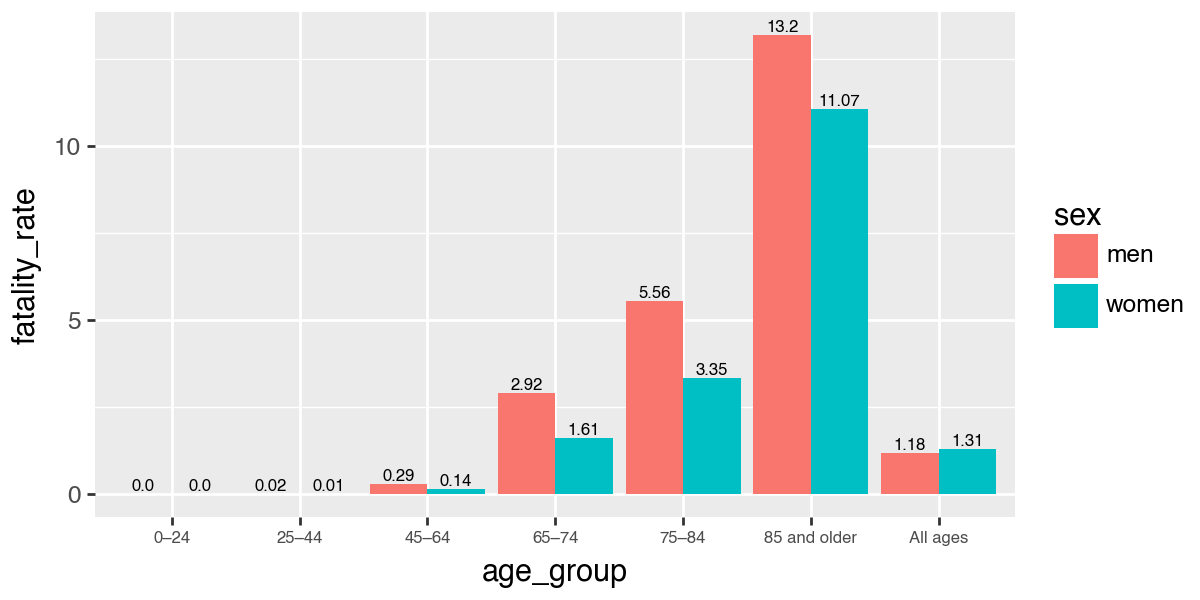

In [106]:
fatalitiy_df = pd.read_csv('../Datasets/Exercise2_datasets/exdata 6/belgium_infection_fatality_rate_june2020.csv')
fatalitiy_df['age_group'] = fatalitiy_df['age_group'].astype('category')

fatalitiy_df = fatalitiy_df.melt(id_vars= 'age_group', var_name= 'sex', value_name= 'fatality_rate')

display(fatalitiy_df.head())

(
    ggplot(fatalitiy_df, aes(x = 'age_group',y = 'fatality_rate', fill = 'sex')) + 
    geom_col(position = 'dodge') + 
    geom_text(aes(label='fatality_rate'), position=position_dodge(width=0.9),
va='bottom',size=6) +
    theme(axis_text_x=element_text(size=6), figure_size= (6,3))
)

The fact that there are more older women than men in Belgium and that older people in general are
more susceptible to Covid19 death may explain why, contrary to each age group, when considering all
ages women have a higher fatality rate.

This is an example of a Simpson’s paradox - when stratifying by a third variable (age) the association (sex
vs fatality rate) changes direction. The possible causal relationships consistent with these associations
would be:

<img src = '../images/Ekran Resmi 2026-02-09 13.37.21.png' width = 500>

----

# Section 04 - Smoking and Datavizitis severity

Consider the following dataset which contains a population of 2000 individuals who got datavizitis. It
consists of the number of cigarettes each individual smokes per day, the severity of their datavizitis and
if they were hospitalized or not.

In [135]:
datavizitis_smoking = pd.read_csv("../Datasets/Exercise2_datasets/exdata 6/datavizitis_smoking.csv")
datavizitis_smoking['hospitalized'] = np.where(datavizitis_smoking['hospitalized'] == 'Yes', 1,0)
datavizitis_smoking['hospitalized'] = datavizitis_smoking['hospitalized'].astype('category')
datavizitis_smoking.head()


,cigarettes_per_day,datavizitis_severity,hospitalized
0,4,0.0,0
1,2,0.0,0
2,2,0.0,0
3,4,0.0,0
4,0,0.0,0


1. Visualize the relationship between the number of cigarettes smoked per day and datavizitis severity
among hospitalized individuals. Make use of geom_smooth(method="lm") to highlight the general trend.

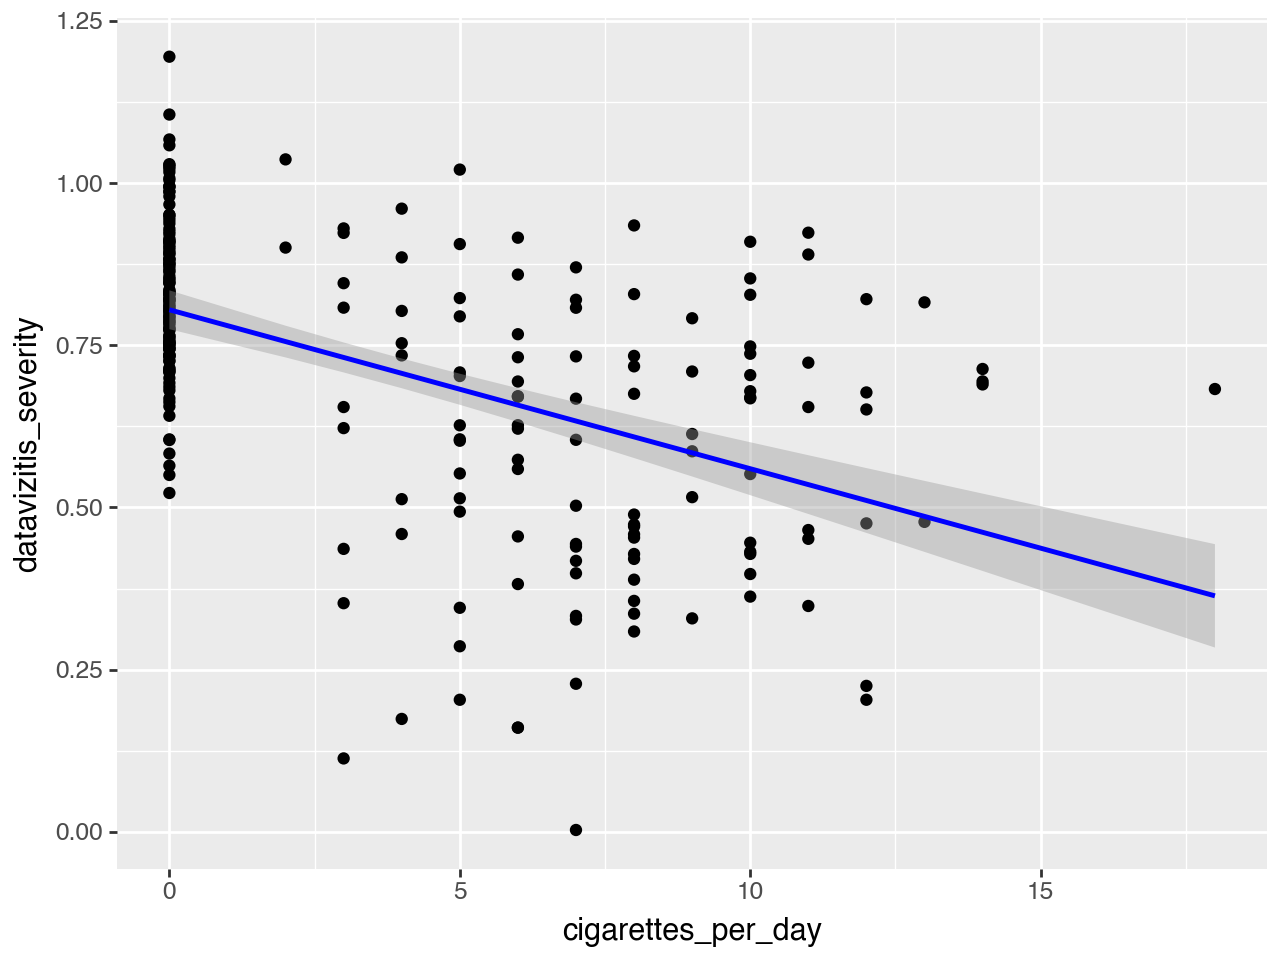

In [136]:
hospitalized_df = datavizitis_smoking[ datavizitis_smoking['hospitalized'] == 1 ]

(
    ggplot(hospitalized_df, aes(x = 'cigarettes_per_day', y = 'datavizitis_severity')) + 
    geom_point() +
    geom_smooth(method = 'lm', color = 'blue') 
)

2. Visualize the relationship between the severity of datavizitis and the number of cigarettes smoked
per day across the entire population. Make use of geom_smooth(method="lm") to highlight the general
trend.

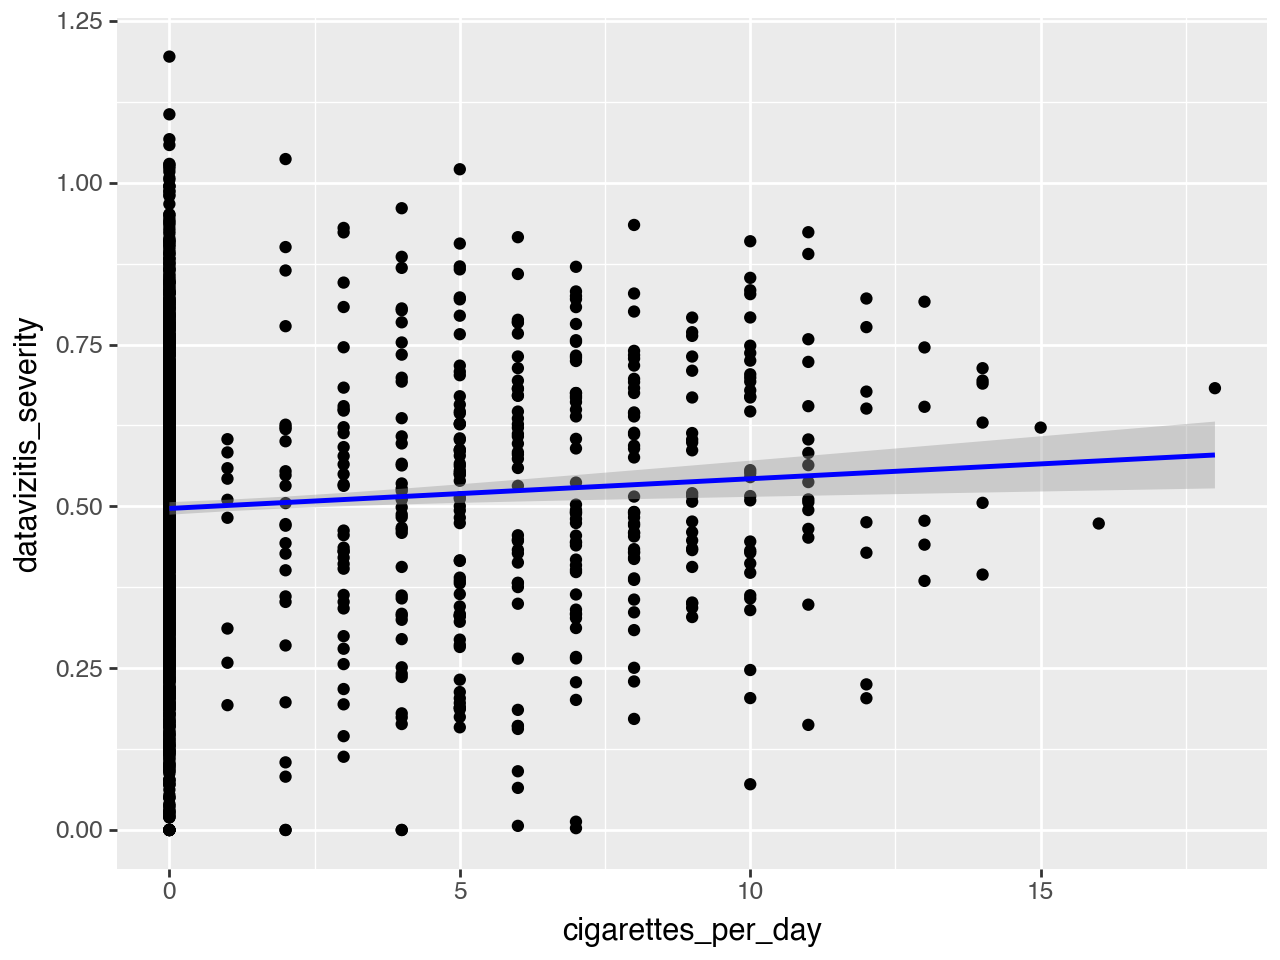

In [137]:
(
    ggplot(datavizitis_smoking, aes(x = 'cigarettes_per_day', y = 'datavizitis_severity')) + 
    geom_point() +
    geom_smooth(method = 'lm', color = 'blue')
)

3. Visualize the same relationship distinguishing between hospitalized and non-hospitalized individuals.

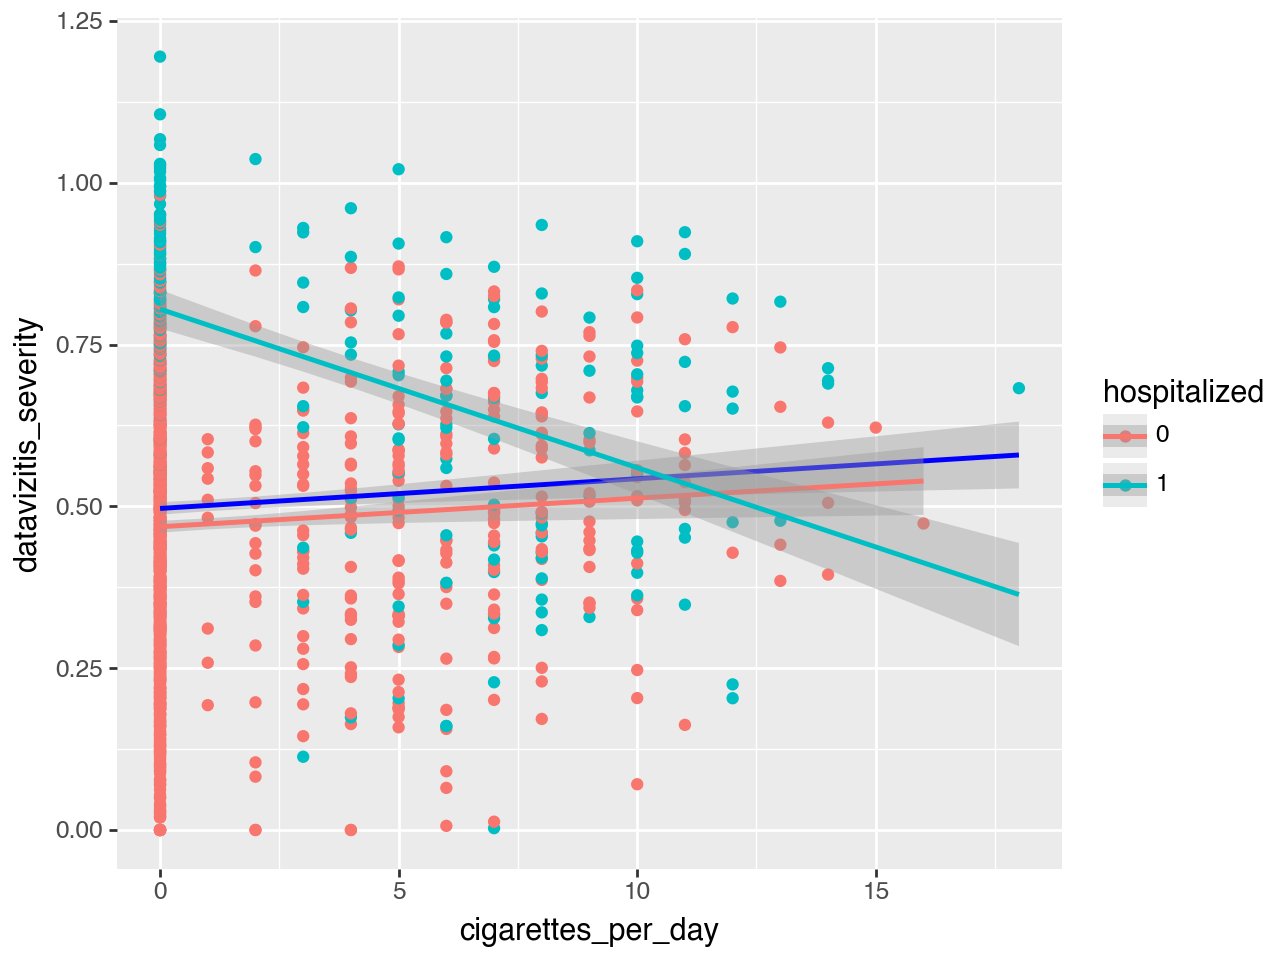

In [140]:
(
    ggplot(datavizitis_smoking, aes(x = 'cigarettes_per_day', y = 'datavizitis_severity', color = 'hospitalized')) +
    geom_point() +
    geom_smooth(aes(group=1), method="lm", color='blue') +
    geom_smooth(method = 'lm')
)

4. Early studies had looked at hospitalized patients who tested positive for Covid19 and their smoking
status. 

They proposed smoking may provide a lower risk of developing severe Covid19 based on a negative
association between Covid19 severity and smoking status. 

Considering the previous results on datavizitis can you come up with a different explanation? Draw a graph with the potential causal relationships you find consistent with the data.

Relate it to one of the situations from the lecture script’s figure 6.3 or Simpson’s paradox.

Considering our dataset, the association between datavizitis severity and the number of cigarettes smoked
per day is only negative when subsetting for hospitalized individuals (and slightly positive considering
all individuals). This scenario can be an example of an association induced by a third-variable of the
type “common consequence” also know as a “collider”.

<img src = '../images/Ekran Resmi 2026-02-09 14.06.12.png' width = 500>

In this case, the third variable would be hospitalization. Both more severe datavizitis and heavier
smoking would lead to a higher probability of hospitalization. The negative association between cigarettes
smoked and datavizitis severity when subsetted by hospitalization can be easier seen in the previous plot
represented by the line fitted on this subset (light blue line) in contrast with the line fitted on all dataset
(dark blue line).

Eventually, assuming Covid19 has a similar relationship with smoking status and hospitalization as
datavizitis, the conclusion of recent studies that reported lower risk of severe Covid19 for smokers based
on hospitalized patients could be attributed to a “common consequence” (a.k.a.) scenario.

This is an example of Berkson’s paradox, identified by Berkson in retrospective data from hospitalized
patients. See https://en.wikipedia.org/wiki/Berkson%27s_paradox

----

# Section 05 - Supporting hypotheses with visualizations

In [199]:
titanic = pd.read_csv('../Datasets/Exercise2_datasets/exdata 6/titanic.csv')
titanic['survived'] = titanic['survived'].astype('category')
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


2. Inspect the data table and make a summary of the variables in the dataset. What is the overall
passenger survival rate?

In [167]:
titanic['survived'].astype(int).mean()

np.float64(0.3819709702062643)

3. Does age associate with survival? Make a plot showing the distribution of age per survival outcome

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 263 rows containing non-finite values.


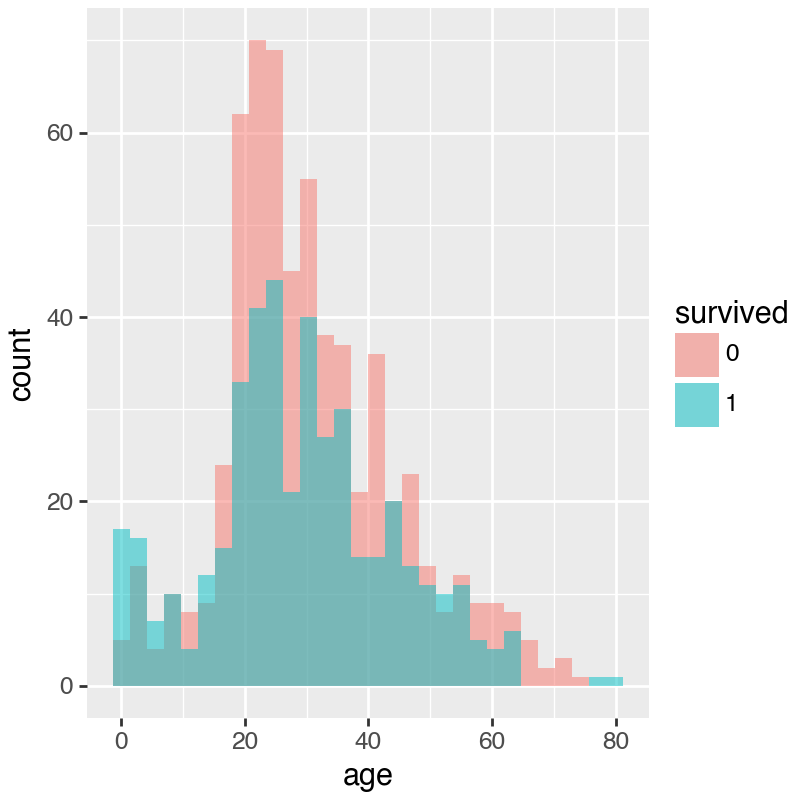

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 263 rows containing non-finite values.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_jitter : Removed 263 rows containing missing values.


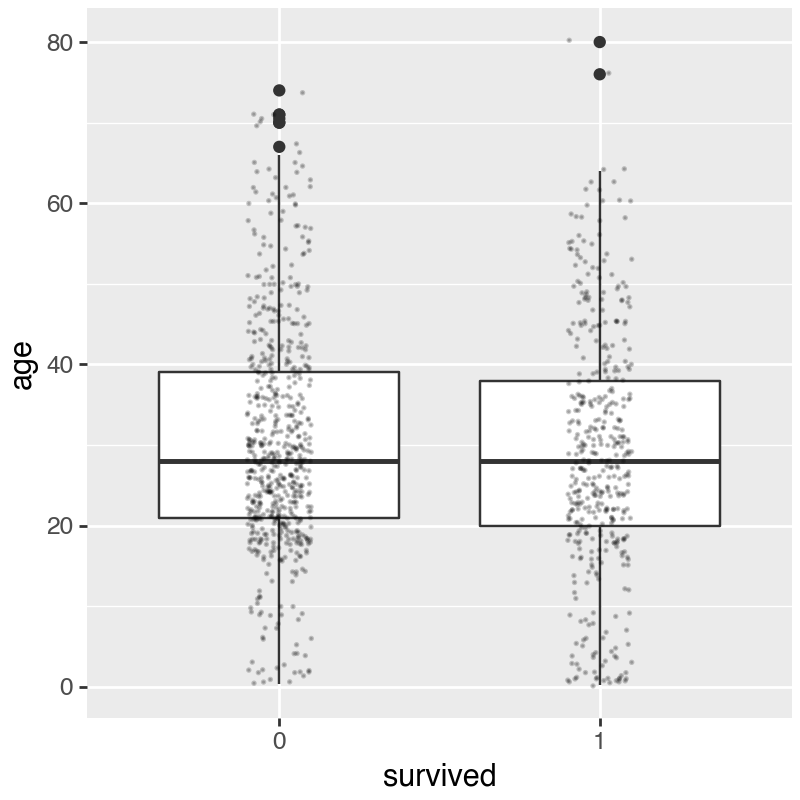

In [175]:
display(
    (
        ggplot(titanic, aes(x='age', fill='survived')) +
        geom_histogram(
            bins=30,
            position='identity',
            alpha=0.5
        ) +
        theme(figure_size=(4,4))
    )
)


display(
    (
        ggplot(titanic, aes(x = 'survived', y = 'age')) + 
        geom_boxplot() + 
        geom_jitter(width = 0.1, alpha = 0.2, size = 0.1) + 
        theme(figure_size= (4,4))
    )
)

4. Visualize the relationship between passenger class (pclass) and survival rate.

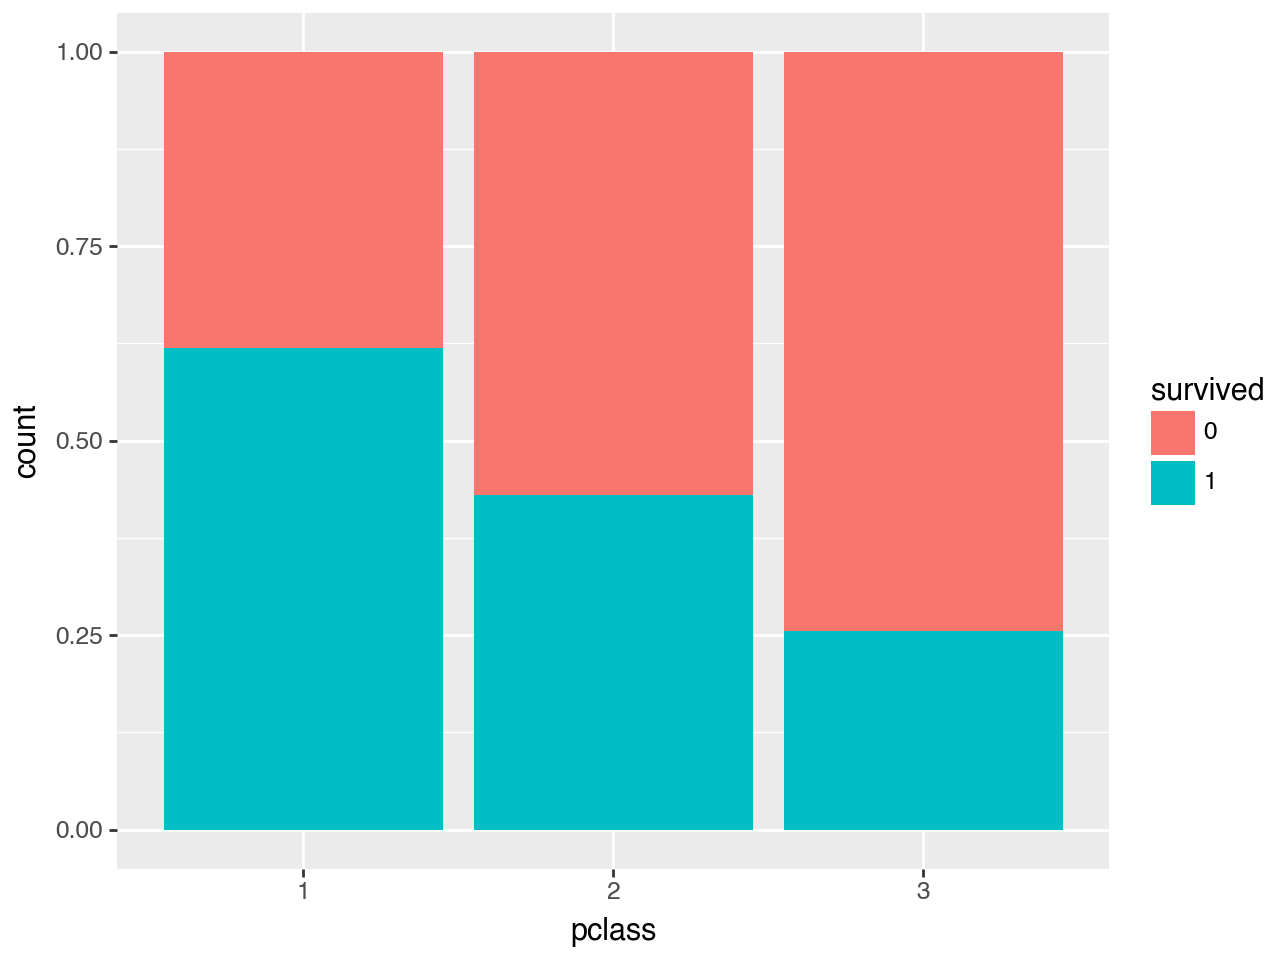

In [183]:
titanic['pclass'] = titanic['pclass'].astype('category')

(
    ggplot(titanic, aes(x = 'pclass', fill = 'survived')) + 
    geom_bar(position = 'fill')
)

5. How is age distributed in each passenger class?

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 263 rows containing non-finite values.


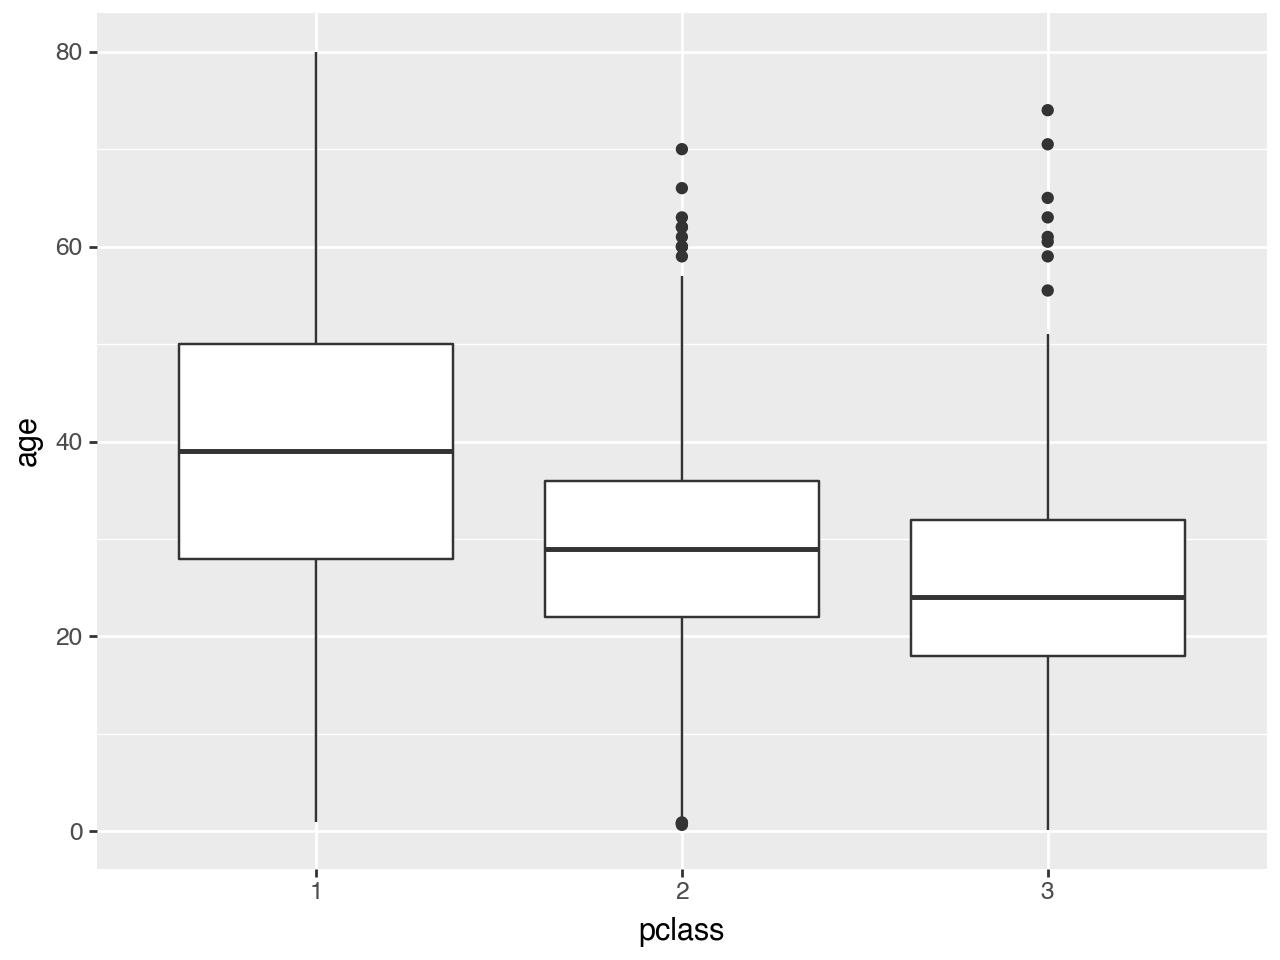

In [185]:
(
    ggplot(titanic, aes('pclass', 'age')) + 
    geom_boxplot()
)

6. Considering the passenger class, do age and survival outcome associate? Given the findings on question
4, comment on the results. Draw a graph with the potential causal relationships you find consistent with
the data. Relate it to one of the situations from the lecture script’s figure 6.3 or Simpson’s paradox.

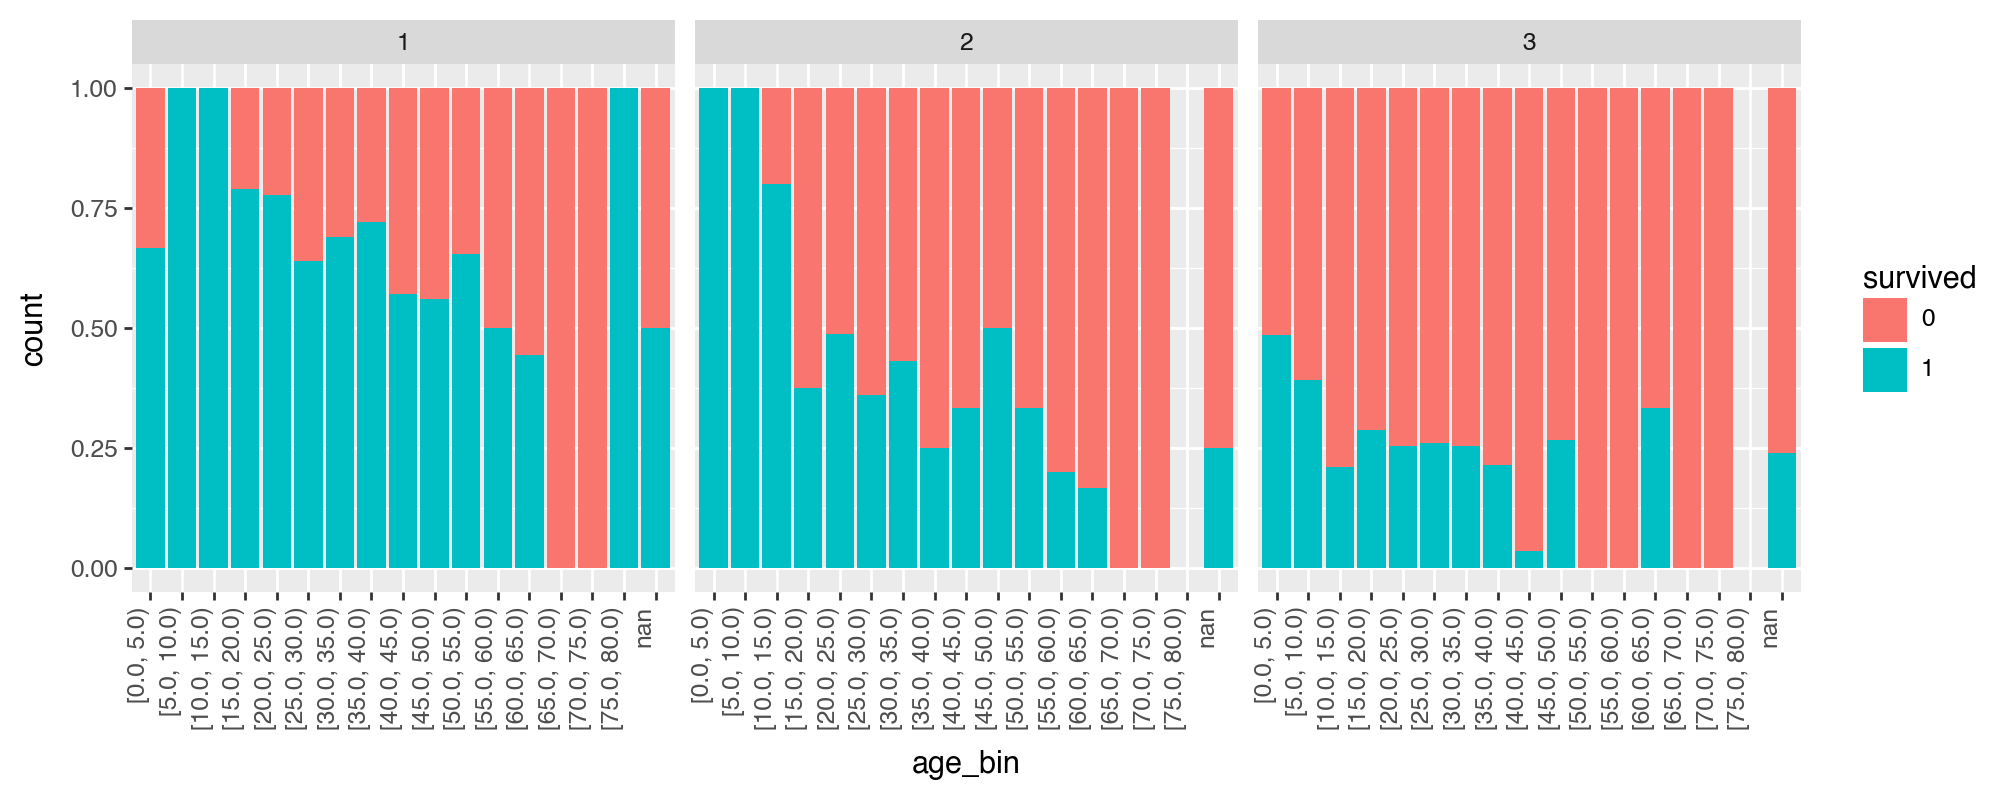

In [198]:
bins = np.arange(0, titanic['age'].max() + 5, 5)
titanic['age_bin'] = pd.cut(titanic['age'], bins = bins, right= False) # False -> [0,5), [5,10)

(
    ggplot(titanic, aes('age_bin', fill = 'survived')) + 
    geom_bar(position = 'fill') + 
    facet_wrap('~pclass') + 
    theme(
        axis_text_x=element_text(rotation=90, ha='right'),
        figure_size=(10, 4)
    )

)

If we facet by passenger class (question 6), we can observe older individuals survived less: 
age -(negative)-> survival 


On question 5 we found that older people were more represented in upper classes (classes 1
and 2).: age -(positive)-> class


We saw on question 4, upper classes are associated with more survival (people in higher classes had easier
access to rescue boats): class -(positive)-> survival 


Such could explain why when considering survival
outcome vs age across all passenger classes (question 3) we don’t see a difference between survival and
age.


We see a negative association between age and survival when faceting by passenger class. That may be
due to the fact that in Titanic, children and women were prioritized, making the median age of people
who survived lower per class.
We could then infer the following causal relationships:

<img src = '../images/Ekran Resmi 2026-02-09 15.04.35.png' width = 500>